# How to define NN

### Imports and reproducibility

In [1]:
!pip install torch torchvision torchaudio

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(0)



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import torch
_ = torch.randn(1)


In [3]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")


Torch version: 2.9.1
CUDA available: False
GPU: CPU only


### Define a simple neural network

In [4]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        # One hidden layer network
        self.fc1 = nn.Linear(in_features=2, out_features=4)
        self.fc2 = nn.Linear(in_features=4, out_features=1)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x


### Initialize the neural network

In [5]:
# Cell 3: Initialize the neural network

model = SimpleNN()
model


SimpleNN(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
)

### Inspect parameters

In [6]:
for name, param in model.named_parameters():
    print(name)
    print(param.data)
    print()


fc1.weight
tensor([[-0.2723,  0.1896],
        [-0.0140,  0.5607],
        [-0.0628,  0.1871],
        [-0.2137, -0.1390]])

fc1.bias
tensor([-0.6755, -0.4683, -0.2915,  0.0262])

fc2.weight
tensor([[ 0.1977,  0.3000, -0.3390, -0.2177]])

fc2.bias
tensor([0.1816])



### One forward pass (no training yet)

In [7]:
x = torch.tensor([[0.5, -1.0]])  # one input sample
y_hat = model(x)

y_hat

tensor([[0.1689]], grad_fn=<AddmmBackward0>)

In [8]:
y_hat[0][0].item()

0.1689065396785736

# Custom NN - from the example

### Network

In [9]:
class DiagramNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2, 2, bias=False)
        self.output = nn.Linear(2, 1, bias=False)

    def forward(self, x):
        h = torch.sigmoid(self.hidden(x))
        y_hat = torch.sigmoid(self.output(h))
        return y_hat


### Initialize weights

In [10]:
model = DiagramNN()

with torch.no_grad():
    model.hidden.weight.copy_(torch.tensor([
        [0.1, 0.8],   # w13, w23
        [0.4, 0.6],   # w14, w24
    ]))

    model.output.weight.copy_(torch.tensor([
        [0.3, 0.9],   # w35, w45
    ]))


### Input and target

In [11]:
x = torch.tensor([[0.35, 0.9]])
y = torch.tensor([[0.5]])


### Forward

In [12]:
y_hat = model(x)
y_hat[0][0].item()


0.690283477306366

Loss

In [13]:
loss = y - y_hat
loss[0][0].item()


-0.19028347730636597

### Backward pass

In [14]:
model.zero_grad()   # ALWAYS do this before backward
loss.backward()


### Gradient Descent update (lr = 1)

In [15]:
lr = 1.0

with torch.no_grad():
    for param in model.parameters():
        param -= lr * param.grad


### Forward pass AFTER the update

In [16]:
y_hat_new = model(x)
y_hat_new[0][0].item()


0.7320550084114075

## training with 100 epochs

### Initialize model

In [17]:
model = DiagramNN()

with torch.no_grad():
    model.hidden.weight.copy_(torch.tensor([
        [0.1, 0.8],
        [0.4, 0.6],
    ]))
    model.output.weight.copy_(torch.tensor([
        [0.3, 0.9],
    ]))


### Input and target

In [18]:
x = torch.tensor([[0.35, 0.9]])
y = torch.tensor([[0.5]])


### Training loop (100 epochs, GD, lr = 1)

In [19]:
lr = 1.0
epochs = 100

losses = []

for epoch in range(epochs):
    # Forward pass
    y_hat = model(x)

    # Custom loss: L = y - y_hat
    loss = y - y_hat

    # Store scalar loss value
    losses.append(loss.item())

    # Backprop
    model.zero_grad()
    loss.backward()

    # Gradient Descent step
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad


### Plot loss vs epochs

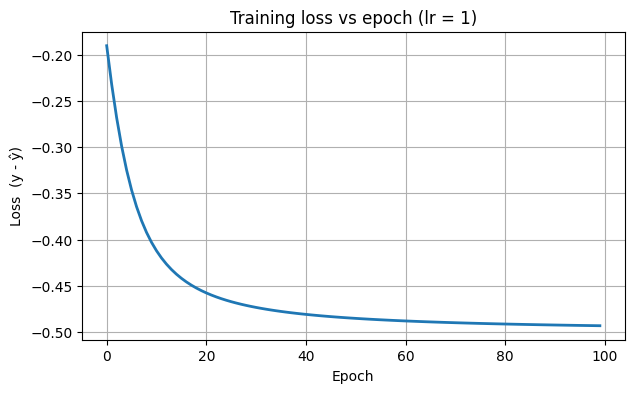

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss  (y - ŷ)")
plt.title("Training loss vs epoch (lr = 1)")
plt.grid(True)
plt.show()


In [21]:
# Cell 7: Forward pass after training

with torch.no_grad():
    y_hat_trained = model(x)

print(f"Input x        : {x.tolist()}")
print(f"Target y       : {y.item():.6f}")
print(f"Predicted ŷ    : {y_hat_trained.item():.6f}")
print(f"Final loss y-ŷ : {(y - y_hat_trained).item():.6f}")


Input x        : [[0.3499999940395355, 0.8999999761581421]]
Target y       : 0.500000
Predicted ŷ    : 0.993352
Final loss y-ŷ : -0.493352


## If loss was $(y-\hat y)^2$:

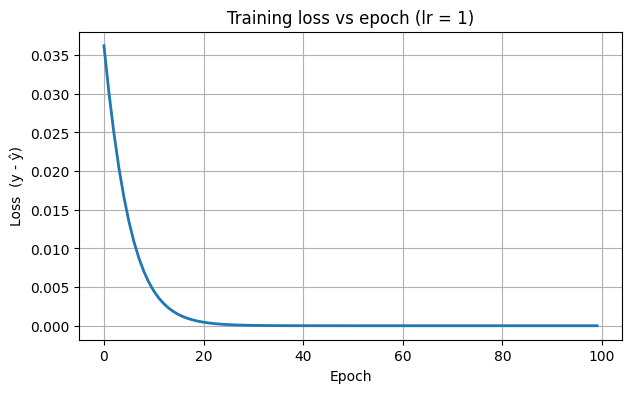

In [22]:
model = DiagramNN()

with torch.no_grad():
    model.hidden.weight.copy_(torch.tensor([
        [0.1, 0.8],
        [0.4, 0.6],
    ]))
    model.output.weight.copy_(torch.tensor([
        [0.3, 0.9],
    ]))


x = torch.tensor([[0.35, 0.9]])
y = torch.tensor([[0.5]])


lr = 1.0
epochs = 100

losses = []

for epoch in range(epochs):
    # Forward pass
    y_hat = model(x)

    # Custom loss: L = y - y_hat
    loss = (y - y_hat)**2

    # Store scalar loss value
    losses.append(loss.item())

    # Backprop
    model.zero_grad()
    loss.backward()

    # Gradient Descent step
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad


plt.figure(figsize=(7, 4))
plt.plot(losses, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss  (y - ŷ)")
plt.title("Training loss vs epoch (lr = 1)")
plt.grid(True)
plt.show()


# Real use oF NN- MNIST dataset

### Imports

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

ן

### Load MNIST dataset

In [24]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)


100.0%
100.0%
100.0%
100.0%


### Data loaders

In [25]:
batch_size = 64

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False
)
epochs = 5


Instead of each forward pass computing gradients on the full 60k training set, we split the training data into mini-batches of 64 images, compute gradients for each batch, and iterate over all batches once per epoch — repeating this process 5 times (5 epochs).

### Visualize 10 digits

Each digit is just a 28×28 array of numbers

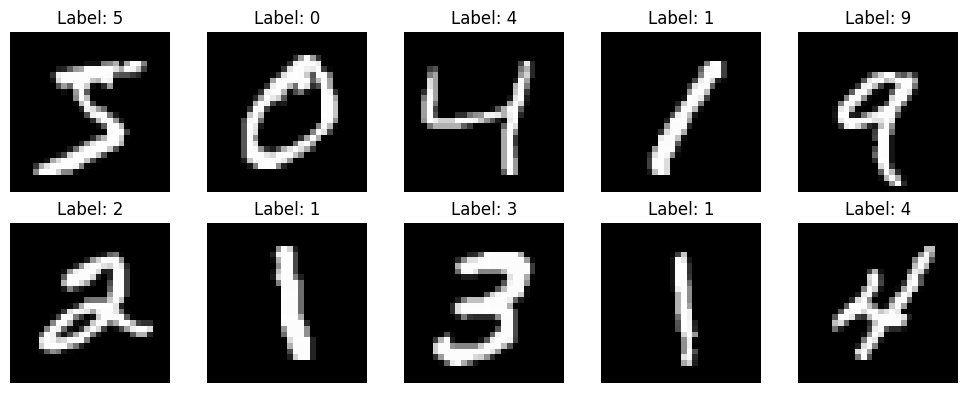

In [26]:
plt.figure(figsize=(10, 4))

for i in range(10):
    image, label = train_dataset[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show()


### Neural Network for MNIST

In [27]:
class MNIST_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)           # logits
        return x


### Initialize model, loss, optimizer

In [28]:
model = MNIST_NN()

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)


### Training loop

In [29]:
losses = []

for epoch in range(epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        # Forward
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


Epoch [1/5], Loss: 0.4385
Epoch [2/5], Loss: 0.2237
Epoch [3/5], Loss: 0.1668
Epoch [4/5], Loss: 0.1335
Epoch [5/5], Loss: 0.1115


### Plot training loss

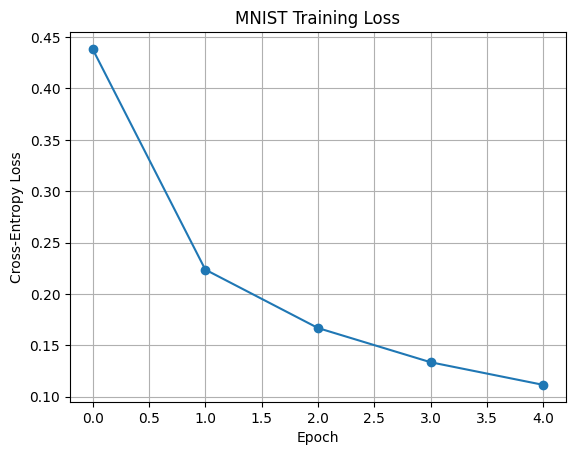

In [30]:
plt.plot(losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("MNIST Training Loss")
plt.grid(True)
plt.show()


### Evaluate on test set (accuracy)

In [31]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total
accuracy


96.61

### Show predictions

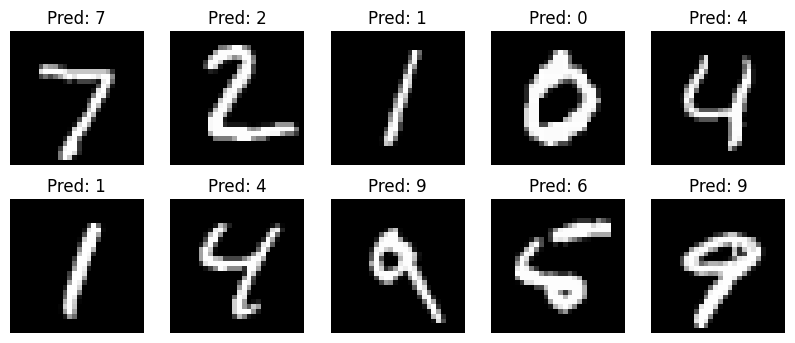

In [32]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {preds[i].item()}")
    plt.axis("off")

plt.show()

### Find misclassified test examples

In [33]:
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mask = preds != labels
        if mask.any():
            misclassified_images.append(images[mask])
            misclassified_preds.append(preds[mask])
            misclassified_labels.append(labels[mask])

# Concatenate all batches
misclassified_images = torch.cat(misclassified_images)
misclassified_preds = torch.cat(misclassified_preds)
misclassified_labels = torch.cat(misclassified_labels)

len(misclassified_images)


339

### Show misclassified images


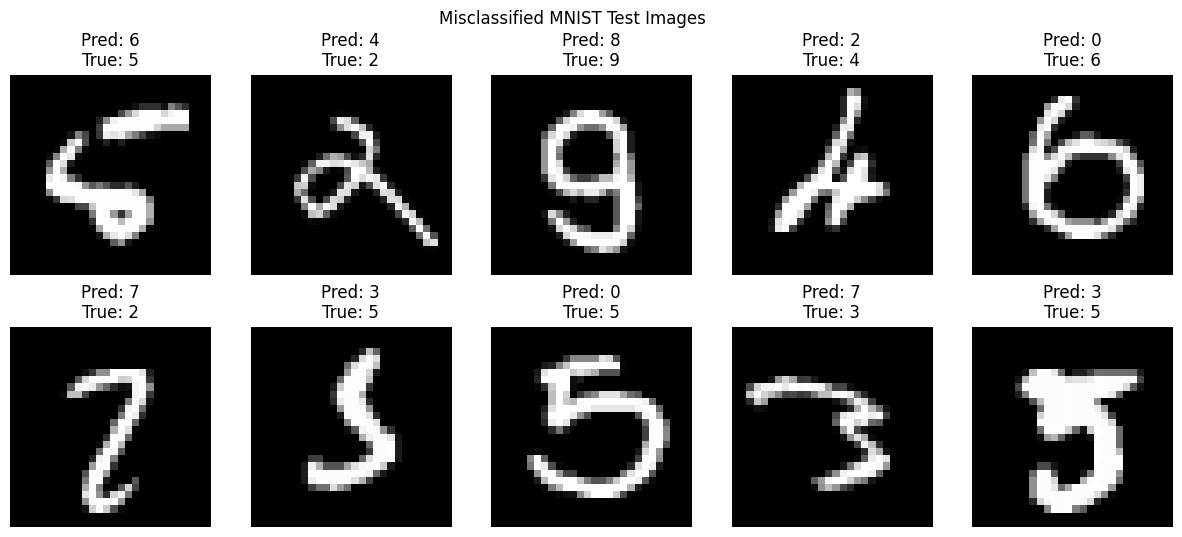

In [34]:
n_show = 10  # number of failures to show

plt.figure(figsize=(15, 6))
for i in range(n_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(misclassified_images[i].squeeze(), cmap="gray")
    plt.title(
        f"Pred: {misclassified_preds[i].item()}\nTrue: {misclassified_labels[i].item()}"
    )
    plt.axis("off")

plt.suptitle("Misclassified MNIST Test Images")
plt.show()
